In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def read_IBMF_data(path, filename):
    data = np.loadtxt(f"{path}/{filename}")
    return data

In [31]:
def read_SIM_data(path, filename):
    fin = open(f"{path}/{filename}", "r")
    data = []
    while True:
        line = fin.readline()
        if not line:
            break
        data.append(float(line.split()[2]))
    return np.array(data)

In [3]:
def order_individual_abundances(data, n_leading=5):
    data = data[data[:, 1].argsort()]
    print(f'First {n_leading} individuals with lowest abundance:')
    for i in range(n_leading):
        print(f"Individual {int(data[i, 0]) + 1}: Abundance {data[i, 1]}")
    print(f'Last {n_leading} individuals with lowest abundance:')
    for i in range(n_leading):
        print(f"Individual {int(data[-i - 1, 0]) + 1}: Abundance {data[-i - 1, 1]}")

In [4]:
def individual_abundances_below_thr(abundances, thr):
    counted_below_thr = np.sum(abundances < thr)
    counted_above_thr = len(abundances) - counted_below_thr
    print(f'Total individuals below threshold {thr}: {counted_below_thr}   percent: {100.0 * counted_below_thr / len(abundances):.2f}%')
    print(f'Total individuals above threshold {thr}: {counted_above_thr}  percent: {100.0 * counted_above_thr / len(abundances):.2f}%')

In [5]:
def get_avg_runtime(path, filename):
    fin = open(f"{path}/{filename}", 'r')
    avg_runtime = 0.0
    avg_runtime_sqr = 0.0
    counter = 0
    while True:
        line = fin.readline()
        if not line:
            break
        avg_runtime += float(line.split()[10])
        avg_runtime_sqr += float(line.split()[10]) ** 2
        counter += 1
    fin.close()
        
    avg_runtime /= counter
    avg_runtime_sqr /= counter
    error_avg_runtime = np.sqrt((avg_runtime_sqr - avg_runtime ** 2) / counter)
    print(f'Average runtime: {avg_runtime} seconds ± {error_avg_runtime} seconds over {counter} runs.')

In [6]:
def plot_histogram_individual_abundances(abundances, n_bins=10):
    plt.hist(abundances, bins=n_bins, density=True, histtype='step')
    plt.xlabel(r'$n_i$')
    plt.ylabel('Frequency')
    plt.show()

In [21]:
def plot_several_histogram_individual_abundances(abundances_list, N_list, n_bins=10):
    for abundances, N in zip(abundances_list, N_list):
        plt.hist(abundances, bins=n_bins, density=True, histtype='step', label=f'N={N}')
    plt.xlabel(r'$n_i$')
    plt.ylabel('Frequency')
    plt.legend()
    plt.show()

In [7]:
def plot_histogram_individual_abundances_log(abundances, n_bins=10):
    logbins = np.logspace(np.log10(np.min(abundances)), np.log10(np.max(abundances)), n_bins)
    plt.hist(abundances, bins=logbins, density=True, histtype='step')
    plt.xscale('log')
    plt.yscale('log')
    plt.xlabel(r'$n_i$')
    plt.ylabel('Frequency')
    plt.show()

In [26]:
# path_in = "/media/david/Data/UH/Grupo_de_investigacion/Ecology/Results/IBMF/One_graph/"
path_in = "/media/david/Seagate Expansion Drive/Salva/Salva_Data_Investigacion/Grupo_de_investigacion/Ecology/Results/IBMF/One_graph/"

In [11]:
filename = 'IBMF_seq_Graph_Extraction_1_Interaction_Matrix_David_Lotka_Volterra_final_av0_0.500_dn_0.500_T_0.015_lambda_1.0e-06_tol_1.0e-06_maxiter_10000_damping_1.00.txt_seedseq_1_seedinit_1.txt'
data = read_IBMF_data(path_in, filename)
abundances_IBMF = data[:, 1]

In [12]:
n_leading = 10
order_individual_abundances(data, n_leading=n_leading)

First 10 individuals with lowest abundance:
Individual 258: Abundance 2.35269e-05
Individual 865: Abundance 4.49374e-05
Individual 900: Abundance 0.000149042
Individual 304: Abundance 0.000304596
Individual 195: Abundance 0.0004828
Individual 90: Abundance 0.000546772
Individual 138: Abundance 0.000585069
Individual 150: Abundance 0.000719252
Individual 397: Abundance 0.000733058
Individual 862: Abundance 0.00199456
Last 10 individuals with lowest abundance:
Individual 43: Abundance 1.86776
Individual 73: Abundance 1.7324
Individual 853: Abundance 1.68176
Individual 267: Abundance 1.65842
Individual 79: Abundance 1.65621
Individual 726: Abundance 1.64301
Individual 14: Abundance 1.64206
Individual 897: Abundance 1.63822
Individual 1022: Abundance 1.63633
Individual 41: Abundance 1.63463


In [49]:
thr = 0.6
individual_abundances_below_thr(abundances_IBMF, thr)

Total individuals below threshold 0.6: 93   percent: 9.08%
Total individuals above threshold 0.6: 931  percent: 90.92%


N=512:
Total individuals below threshold 0.6: 50   percent: 9.77%
Total individuals above threshold 0.6: 462  percent: 90.23%

N=1024:
Total individuals below threshold 0.6: 89   percent: 8.69%
Total individuals above threshold 0.6: 935  percent: 91.31%

N=2048:
Total individuals below threshold 0.6: 183   percent: 8.94%
Total individuals above threshold 0.6: 1865  percent: 91.06%

N=4096:
Total individuals below threshold 0.6: 361   percent: 8.81%
Total individuals above threshold 0.6: 3735  percent: 91.19%

N=8192:
Total individuals below threshold 0.6: 663   percent: 8.09%
Total individuals above threshold 0.6: 7529  percent: 91.91%

N=16384:
Total individuals below threshold 0.6: 1410   percent: 8.61%
Total individuals above threshold 0.6: 14974  percent: 91.39%

N=32768:
Total individuals below threshold 0.6: 2835   percent: 8.65%
Total individuals above threshold 0.6: 29933  percent: 91.35%



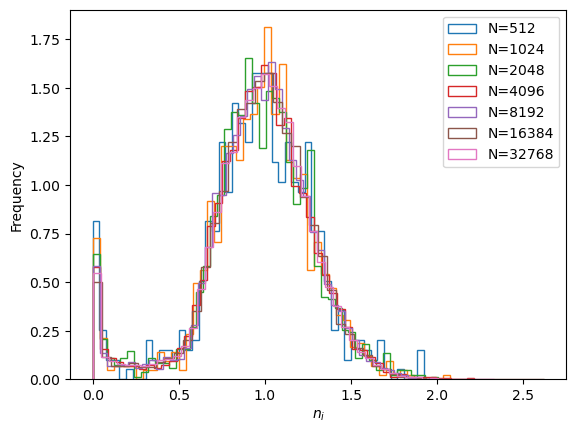

In [27]:
thr = 0.6
N_list = [512, 1024, 2048, 4096, 8192, 16384, 32768]
abundances_IBMF_list = []
for N in N_list:
    filename = f'IBMF_seq_gr_inside_RRG_eps_0.000_mu_0.000_sigma_0.150_N_{N}_c_3_seedgraph_1_Lotka_Volterra_final_av0_0.500_dn_0.500_T_0.015_lambda_1.0e-06_tol_1.0e-08_maxiter_10000_damping_0.20_averages_seedseq_1_seedinit_1.txt'
    data = read_IBMF_data(path_in, filename)
    abundances_IBMF = data[:, 1]
    abundances_IBMF_list.append(abundances_IBMF)
    print(f"N={N}:")
    individual_abundances_below_thr(abundances_IBMF, thr)
    print()

plot_several_histogram_individual_abundances(abundances_IBMF_list, N_list, n_bins=50)

N=512:
Total individuals below threshold 0.6: 34   percent: 6.64%
Total individuals above threshold 0.6: 478  percent: 93.36%

N=1024:
Total individuals below threshold 0.6: 91   percent: 8.89%
Total individuals above threshold 0.6: 933  percent: 91.11%

N=2048:
Total individuals below threshold 0.6: 157   percent: 7.67%
Total individuals above threshold 0.6: 1891  percent: 92.33%

N=4096:
Total individuals below threshold 0.6: 324   percent: 7.91%
Total individuals above threshold 0.6: 3772  percent: 92.09%

N=8192:
Total individuals below threshold 0.6: 614   percent: 7.50%
Total individuals above threshold 0.6: 7578  percent: 92.50%

N=16384:
Total individuals below threshold 0.6: 1268   percent: 7.74%
Total individuals above threshold 0.6: 15116  percent: 92.26%

N=32768:
Total individuals below threshold 0.6: 2536   percent: 7.74%
Total individuals above threshold 0.6: 30232  percent: 92.26%



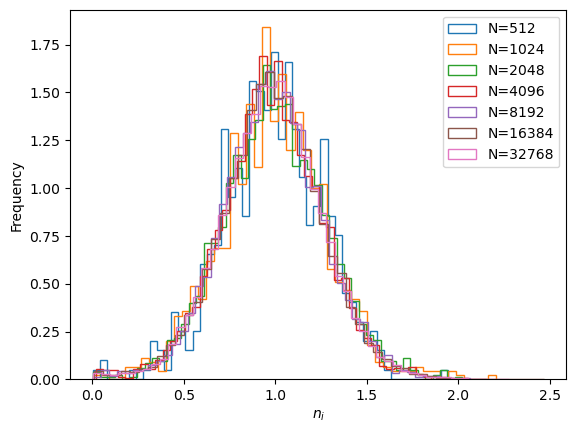

In [39]:
thr = 0.6
N_list = [512, 1024, 2048, 4096, 8192, 16384, 32768]
abundances_SIM_list = []
for N in N_list:
    path_in = f"/media/david/Seagate Expansion Drive/Salva/Salva_Data_Investigacion/Grupo_de_investigacion/Ecology/Langevin/Results/One_graph/Several_N/epsilon_0.000_Partially_AsymGauss_lambda_1e-06_h_0.01/N_{N}_c_3.00/Equilibrium_Points/"
    filename = 'Lotka-Volterra_mu_0.000_sigma_0.150_T_0.015_Extraction_1_Measure_1_Equilibrium_Points.txt'
    abundances_SIM = read_SIM_data(path_in, filename)
    abundances_SIM_list.append(abundances_SIM)
    print(f"N={N}:")
    individual_abundances_below_thr(abundances_SIM, thr)
    print()

plot_several_histogram_individual_abundances(abundances_SIM_list, N_list, n_bins=50)

In [51]:
filename = 'IBMF_seq_Graph_Extraction_1_Interaction_Matrix_David_Lotka_Volterra_T_0.015_lambda_1e-6_0.500_dn_0.500_ninitcond_100_tol_1e-6_maxiter_10000_damping_1.0_nseq_1.txt'
get_avg_runtime(path_in, filename)

Average runtime: 0.021959999999999976 seconds ± 0.0003443602764547726 seconds over 100 runs.


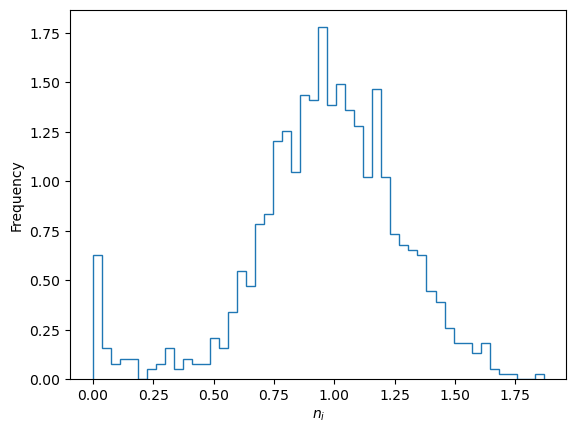

In [52]:
nbins = 50
plot_histogram_individual_abundances(abundances_IBMF, n_bins=nbins)

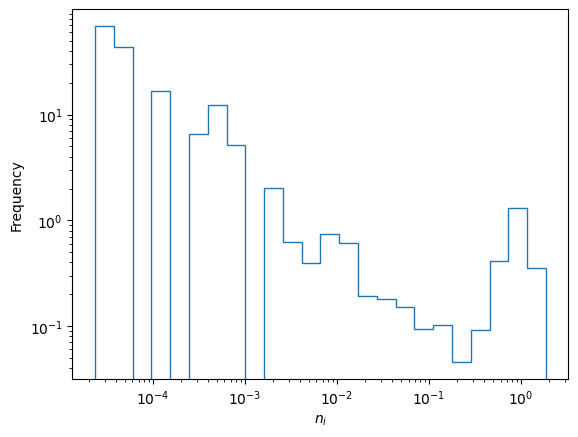

In [54]:
nbins = 25
plot_histogram_individual_abundances_log(abundances_IBMF, n_bins=nbins)

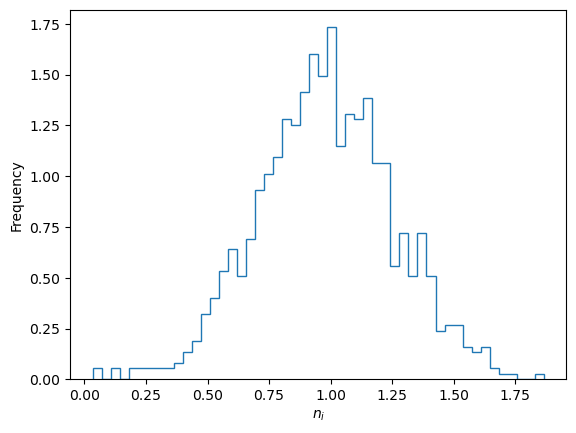

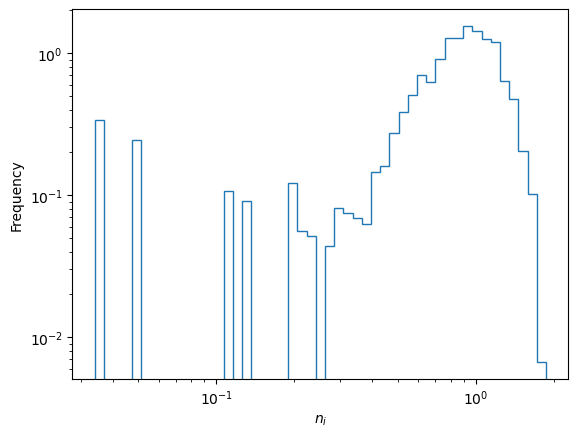

In [61]:
path_in_SIM = "/media/david/Data/UH/Grupo_de_investigacion/Ecology/Langevin/Results/One_graph/"
# path_in = "/media/david/Seagate Expansion Drive/Salva/Salva_Data_Investigacion/Grupo_de_investigacion/Ecology/Langevin/Results/One_graph/"
filename_SIM = 'Lotka-Volterra_mu_0.0_sigma_0.150_T_0.015_Extraction_1_Average_over_100_Measure_Equilibrium_Point.txt'
data = read_IBMF_data(path_in_SIM, filename_SIM)
abundances_SIM = data[:, 0]
nbins = 50
plot_histogram_individual_abundances(abundances_SIM, n_bins=nbins)
nbins = 50
plot_histogram_individual_abundances_log(abundances_SIM, n_bins=nbins)

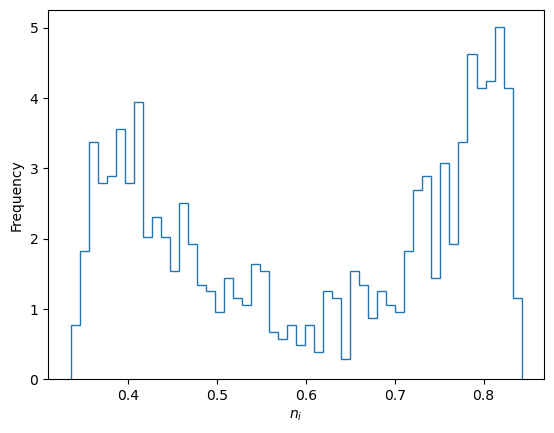

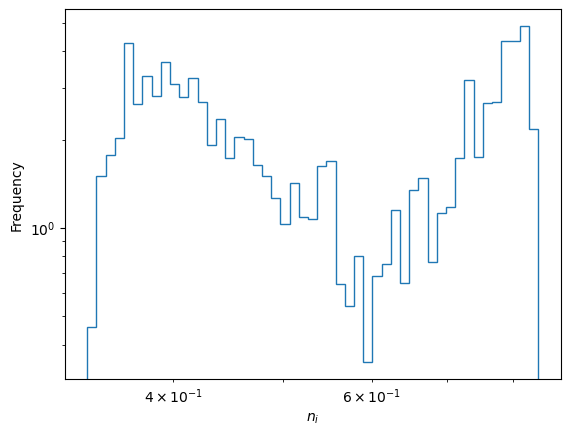

In [63]:
path_in = "/home/david/Data/UH/Grupo_de_investigacion/Ecology"
filename = 'IBMF_seq_gr_inside_RRG_eps_1.000_mu_0.080_sigma_0.000_N_1024_c_3_seedgraph_1_Lotka_Volterra_final_av0_0.500_dn_0.500_T_0.030_lambda_1.0e-06_tol_1.0e-06_maxiter_10000_damping_1.00.txt_seedseq_1_seedinit_1.txt'
data = read_IBMF_data(path_in, filename)
abundances = data[:, 1]
nbins = 50
plot_histogram_individual_abundances(abundances, n_bins=nbins)
nbins = 50
plot_histogram_individual_abundances_log(abundances, n_bins=nbins)

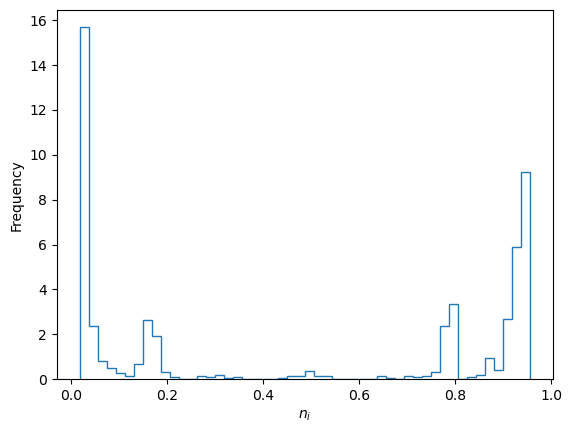

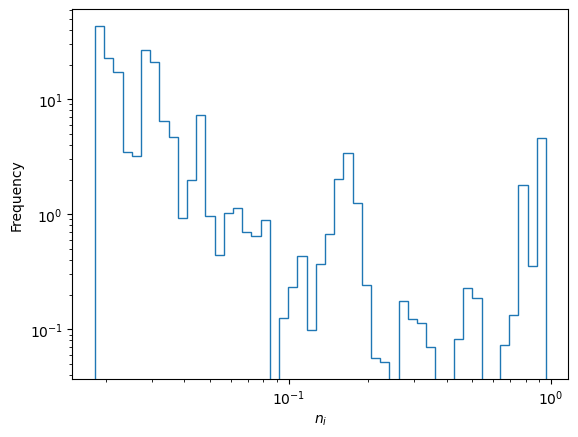

In [64]:
path_in = "/home/david/Data/UH/Grupo_de_investigacion/Ecology"
filename = 'IBMF_seq_gr_inside_RRG_eps_1.000_mu_0.120_sigma_0.000_N_1024_c_3_seedgraph_1_Lotka_Volterra_final_av0_0.500_dn_0.500_T_0.030_lambda_1.0e-06_tol_1.0e-06_maxiter_10000_damping_1.00.txt_seedseq_1_seedinit_1.txt'
data = read_IBMF_data(path_in, filename)
abundances = data[:, 1]
nbins = 50
plot_histogram_individual_abundances(abundances, n_bins=nbins)
nbins = 50
plot_histogram_individual_abundances_log(abundances, n_bins=nbins)

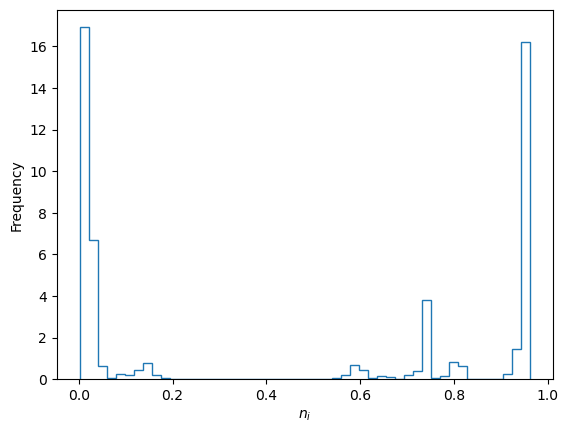

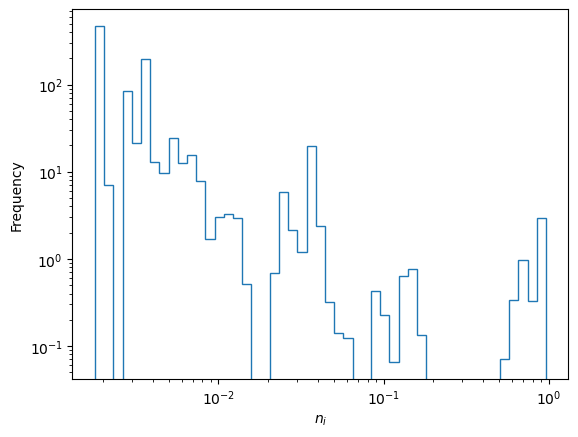

In [65]:
path_in = "/home/david/Data/UH/Grupo_de_investigacion/Ecology"
filename = 'IBMF_seq_gr_inside_RRG_eps_1.000_mu_0.160_sigma_0.000_N_1024_c_3_seedgraph_1_Lotka_Volterra_final_av0_0.500_dn_0.500_T_0.030_lambda_1.0e-06_tol_1.0e-06_maxiter_10000_damping_1.00.txt_seedseq_1_seedinit_1.txt'
data = read_IBMF_data(path_in, filename)
abundances = data[:, 1]
nbins = 50
plot_histogram_individual_abundances(abundances, n_bins=nbins)
nbins = 50
plot_histogram_individual_abundances_log(abundances, n_bins=nbins)

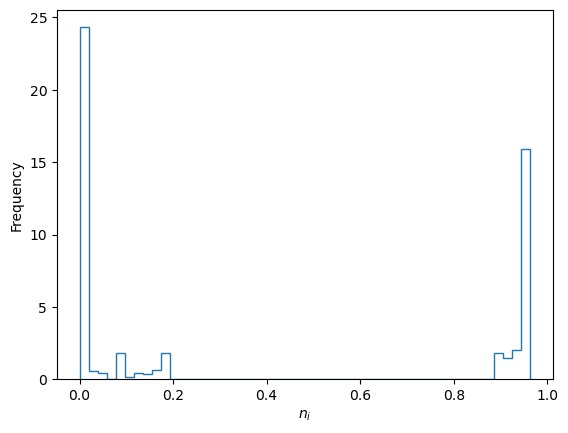

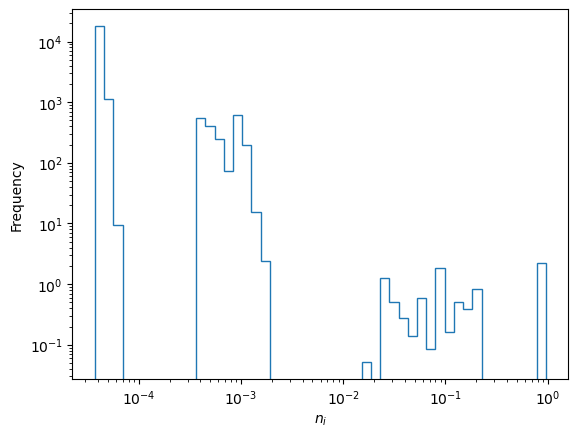

In [67]:
path_in = "/home/david/Data/UH/Grupo_de_investigacion/Ecology"
filename = 'IBMF_seq_gr_inside_RRG_eps_1.000_mu_0.260_sigma_0.000_N_16384_c_3_seedgraph_1_Lotka_Volterra_final_av0_0.500_dn_0.500_T_0.030_lambda_1.0e-06_tol_1.0e-06_maxiter_10000_damping_1.00.txt_seedseq_1_seedinit_1.txt'
data = read_IBMF_data(path_in, filename)
abundances = data[:, 1]
nbins = 50
plot_histogram_individual_abundances(abundances, n_bins=nbins)
nbins = 50
plot_histogram_individual_abundances_log(abundances, n_bins=nbins)